# PyBullet vs Swift `wind` / `rlvec` headless — One-Step Check

Validates the two new headless modules on known standard inputs:
- **wind** = `swift_physics_headless_wind.py` (scalar RK4, single drone)
- **rlvec** = `swift_physics_headless_rlvec.py` (N=1 vectorized RK4 path from `swift_rl_env.py`)

Checks:
1. **Analytic tests** (free fall, hover, pure torque, pure yaw) — exact known answers
2. **wind vs rlvec** — should agree to ~1e-12 (same math, different code path)
3. **Both vs PyBullet** on 1000+ random states, same wrench, one dt

## Steps
1. Run Cell 1 (install)
2. Run Cell 2 — upload **all three**: `swift_physics_headless_wind.py`, `swift_physics_headless_rlvec.py`, **`swift_rl_env.py`**
3. Run the remaining cells
4. Download `results_wind_rlvec.txt` and `comparison_wind_rlvec.png`

**Note:** thrust-only wrench is passed to Swift (it adds gravity itself); PyBullet gets the same wrench with gravity ON, so gravity is not double counted.

In [1]:
# Cell 1: Install
!pip install pybullet scipy -q
import pybullet, scipy
print('pybullet OK  scipy', scipy.__version__)

  Preparing metadata (setup.py) ... done
pybullet OK  scipy 1.16.3


In [6]:
# Cell 2: Upload files
from google.colab import files
print('Upload swift_physics_headless_wind.py, swift_physics_headless_rlvec.py AND swift_rl_env.py')
uploaded = files.upload()
print('Got:', list(uploaded.keys()))

Upload swift_physics_headless_wind.py, swift_physics_headless_rlvec.py AND swift_rl_env.py


Saving wind_rlvec_vs_pybullet.ipynb to wind_rlvec_vs_pybullet.ipynb
Saving swift_rl_env.py to swift_rl_env.py
Saving swift_demo_wind_only.py to swift_demo_wind_only.py
Got: ['wind_rlvec_vs_pybullet.ipynb', 'swift_rl_env.py', 'swift_demo_wind_only.py']


In [7]:
# Cell 3: Imports
import sys, importlib, time, numpy as np, matplotlib.pyplot as plt
import pybullet as p, pybullet_data
sys.path.insert(0, '/content')

import swift_physics_headless_wind as wind
try:
    import swift_physics_headless_rlvec as rlvec
except Exception as e:
    raise RuntimeError(f'rlvec import failed (needs swift_rl_env.py and its deps): {e}')
importlib.reload(wind); importlib.reload(rlvec)

params = wind.PARAMS_NANOBENCH
mass, J, dt = params['m'], params['J'], 0.01
hover_omega = wind.hover_omega_from_params(params)
rng = np.random.default_rng(42)

print('wind', wind.__version__, '| rlvec', rlvec.__version__)
print(f'm={mass*1000:.1f}g  hover_Omega={hover_omega[0]:.1f} rad/s')

# Parameter consistency between the two modules
pr = rlvec.PARAMS_NANOBENCH
print('\\nParameter consistency (wind vs rlvec):')
for k in ['m','J','J_mp','g_W','r_P','zeta','spin_sign','c_l','c_d','k_mot','Omega_max']:
    a, b = np.asarray(params[k], float), np.asarray(pr[k], float)
    same = a.shape == b.shape and np.allclose(a, b, rtol=1e-9, atol=0)
    print(f'  {k:10s} {"OK" if same else "MISMATCH"}' + ('' if same else f'  wind={a.tolist()} rlvec={b.tolist()}'))
# make sure rlvec sees the same J form the step function expects

wind wind-only-headless-1.0 | rlvec rlvec-headless-1.0
m=40.8g  hover_Omega=1956.2 rad/s
\nParameter consistency (wind vs rlvec):
  m          OK
  J          MISMATCH  wind=[[2.3951e-05, 0.0, 0.0], [0.0, 2.3951e-05, 0.0], [0.0, 0.0, 3.2347e-05]] rlvec=[2.3951e-05, 2.3951e-05, 3.2347e-05]
  J_mp       OK
  g_W        OK
  r_P        OK
  zeta       OK
  spin_sign  OK
  c_l        OK
  c_d        OK
  k_mot      OK
  Omega_max  OK


In [8]:
# Cell 4: Helpers + PyBullet setup (gravity ON, thrust-only wrench)
def wrench(Omega):
    """Thrust/torque only (NO gravity) - Swift adds gravity internally."""
    f_props, tau_props = wind.propeller_force_torque(Omega, params['c_l'], params['c_d'], params['spin_sign'])
    return wind.aggregate_forces(f_props, tau_props, params['r_P'])

def wrench_rlvec(Omega):
    f_props, tau_props = rlvec.propeller_force_torque(Omega, params['c_l'], params['c_d'], params['spin_sign'])
    return rlvec.aggregate_forces(f_props, tau_props, params['r_P'])

def setup_pybullet():
    cl = p.connect(p.DIRECT)
    p.resetSimulation(physicsClientId=cl)
    p.setGravity(0, 0, -9.81, physicsClientId=cl)
    p.setTimeStep(dt, physicsClientId=cl)
    col = p.createCollisionShape(p.GEOM_SPHERE, radius=0.05, physicsClientId=cl)
    bd = p.createMultiBody(baseMass=mass, baseCollisionShapeIndex=col,
                           basePosition=[0,0,1], physicsClientId=cl)
    p.changeDynamics(bd, -1, localInertiaDiagonal=(J[0,0],J[1,1],J[2,2]),
                     linearDamping=0.0, angularDamping=0.0, physicsClientId=cl)
    return cl, bd

def pybullet_step(cl, bd, pos, q_wxyz, vel, omega_B, f_body, tau_body):
    qxyzw = np.array([q_wxyz[1], q_wxyz[2], q_wxyz[3], q_wxyz[0]])
    p.resetBasePositionAndOrientation(bd, pos.tolist(), qxyzw.tolist(), physicsClientId=cl)
    R = np.array(p.getMatrixFromQuaternion(qxyzw, physicsClientId=cl)).reshape(3,3)
    p.resetBaseVelocity(bd, vel.tolist(), (R @ omega_B).tolist(), physicsClientId=cl)
    p.applyExternalForce(bd, -1, f_body.tolist(), [0,0,0], p.LINK_FRAME, physicsClientId=cl)
    p.applyExternalTorque(bd, -1, tau_body.tolist(), p.LINK_FRAME, physicsClientId=cl)
    p.stepSimulation(physicsClientId=cl)
    pos_n, q_n = p.getBasePositionAndOrientation(bd, physicsClientId=cl)
    vel_n, omW = p.getBaseVelocity(bd, physicsClientId=cl)
    R_n = np.array(p.getMatrixFromQuaternion(q_n, physicsClientId=cl)).reshape(3,3)
    q_n = np.array(q_n)
    return np.array(pos_n), np.array([q_n[3],q_n[0],q_n[1],q_n[2]]), np.array(vel_n), R_n.T @ np.array(omW)

def quat_angle_deg(q1, q2):
    d = abs(np.clip(np.dot(q1/np.linalg.norm(q1), q2/np.linalg.norm(q2)), -1, 1))
    return np.degrees(2*np.arccos(d))

def make_state(pos, q, vel, omega):
    q = np.array(q, float); q /= np.linalg.norm(q)
    return dict(p_WB=np.array(pos,float), q_WB=q, v_WB=np.array(vel,float), omega_B=np.array(omega,float))

MODS = {'wind': wind.rk4_rigid_body_step, 'rlvec': rlvec.rk4_rigid_body_step}
client, body = setup_pybullet()
print('PyBullet ready')

PyBullet ready


In [9]:
# Cell 5: Analytic known-answer tests (no PyBullet)
g = 9.81
def check(name, fn_state, f, tau, expected):
    print(f'\\n[{name}]')
    ok_all = True
    for mn, step in MODS.items():
        s = step(fn_state, f, tau, params, dt)
        errs = {k: np.max(np.abs(s[k] - v)) for k, v in expected.items()}
        ok = all(e < 1e-9 for e in errs.values()); ok_all &= ok
        print(f'  {mn:6s} ' + ('PASS' if ok else 'FAIL') + '  ' + '  '.join(f'{k}:{e:.2e}' for k, e in errs.items()))
    return ok_all

z3 = np.zeros(3); ident = [1,0,0,0]
results_analytic = []

# 1. Perfect hover: thrust = weight -> state unchanged
f_h, t_h = wrench(hover_omega)
s = make_state([0,0,1], ident, z3, z3)
results_analytic.append(check('hover (should not move)', s, f_h, t_h,
    dict(p_WB=np.array([0,0,1.]), v_WB=z3, omega_B=z3)))

# 2. Free fall: zero wrench
s = make_state([0,0,1], ident, z3, z3)
results_analytic.append(check('free fall', s, z3, z3,
    dict(p_WB=np.array([0,0,1-0.5*g*dt**2]), v_WB=np.array([0,0,-g*dt]))))

# 3. Free fall with initial velocity
v0 = np.array([1.0, -2.0, 3.0])
s = make_state([0,0,1], ident, v0, z3)
results_analytic.append(check('ballistic w/ initial velocity', s, z3, z3,
    dict(p_WB=np.array([0,0,1])+v0*dt+np.array([0,0,-0.5*g*dt**2]), v_WB=v0+np.array([0,0,-g*dt]))))

# 4. Pure torque about each axis: omega = J^-1 tau dt, (thrust cancels gravity)
for ax in range(3):
    tau = np.zeros(3); tau[ax] = 1e-4
    f = np.array([0,0,mass*g])
    s = make_state([0,0,1], ident, z3, z3)
    exp_w = np.zeros(3); exp_w[ax] = tau[ax]/J[ax,ax]*dt
    results_analytic.append(check(f'pure torque axis {"xyz"[ax]}', s, f, tau,
        dict(omega_B=exp_w, v_WB=z3)))

# 5. Constant spin about z (no torque): quaternion = rotation by w*dt about z
w_z = 3.0
s = make_state([0,0,1], ident, z3, [0,0,w_z])
a = w_z*dt/2
results_analytic.append(check('constant yaw rate', s, np.array([0,0,mass*g]), z3,
    dict(q_WB=np.array([np.cos(a),0,0,np.sin(a)]), omega_B=np.array([0,0,w_z]))))

# 6. Tilted 30 deg about x, thrust=weight: lateral accel = g*sin(30)
a = np.radians(30)/2
s = make_state([0,0,1], [np.cos(a),np.sin(a),0,0], z3, z3)
R = wind.quat2rotm_manual(s['q_WB'])
exp_a = R @ np.array([0,0,mass*g])/mass + np.array([0,0,-g])
results_analytic.append(check('tilted 30deg thrust=weight', s, np.array([0,0,mass*g]), z3,
    dict(v_WB=exp_a*dt, p_WB=np.array([0,0,1])+0.5*exp_a*dt**2)))

print('\\nANALYTIC:', 'ALL PASS' if all(results_analytic) else 'SOME FAILED')

\n[hover (should not move)]
  wind   PASS  p_WB:0.00e+00  v_WB:1.78e-17  omega_B:0.00e+00
  rlvec  PASS  p_WB:0.00e+00  v_WB:1.78e-17  omega_B:0.00e+00
\n[free fall]
  wind   PASS  p_WB:0.00e+00  v_WB:0.00e+00
  rlvec  PASS  p_WB:0.00e+00  v_WB:0.00e+00
\n[ballistic w/ initial velocity]
  wind   PASS  p_WB:0.00e+00  v_WB:0.00e+00
  rlvec  PASS  p_WB:0.00e+00  v_WB:0.00e+00
\n[pure torque axis x]
  wind   FAIL  omega_B:1.39e-17  v_WB:6.83e-06
  rlvec  FAIL  omega_B:1.39e-17  v_WB:6.83e-06
\n[pure torque axis y]
  wind   FAIL  omega_B:1.39e-17  v_WB:6.83e-06
  rlvec  FAIL  omega_B:1.39e-17  v_WB:6.83e-06
\n[pure torque axis z]
  wind   PASS  omega_B:3.47e-18  v_WB:0.00e+00
  rlvec  PASS  omega_B:3.47e-18  v_WB:0.00e+00
\n[constant yaw rate]
  wind   PASS  q_WB:6.33e-12  omega_B:0.00e+00
  rlvec  PASS  q_WB:6.33e-12  omega_B:0.00e+00
\n[tilted 30deg thrust=weight]
  wind   PASS  v_WB:6.94e-18  p_WB:5.42e-20
  rlvec  PASS  v_WB:6.94e-18  p_WB:5.42e-20
\nANALYTIC: SOME FAILED


In [10]:
# Cell 6: Generate test cases
def gen_tests(n=1000):
    cases = []
    def add(label, pos, q, vel, omega, Omega):
        q = np.array(q, float); q /= np.linalg.norm(q)
        cases.append(dict(label=label, pos=np.array(pos,float), q=q, vel=np.array(vel,float),
                          omega=np.array(omega,float),
                          Omega=np.clip(np.array(Omega,float), 50., params['Omega_max'])))
    add('hover_perfect', [0,0,1], [1,0,0,0], [0,0,0], [0,0,0], hover_omega)
    add('hover_2pct_noise', [0,0,1], [1,0,0,0], [0,0,0], [0,0,0],
        hover_omega + rng.uniform(-0.02,0.02,4)*hover_omega[0])
    a = np.radians(10)/2
    add('aggressive_pitch', [0.5,0,1.2], [np.cos(a),np.sin(a),0,0], [1,0,0.2], [2,0.5,0.1],
        hover_omega + np.array([0.15,0.15,-0.15,-0.15])*hover_omega[0])
    a = np.radians(30)/2
    add('yaw_climb', [0,0.5,0.8], [np.cos(a),0,0,np.sin(a)], [0,0.5,0.8], [0,0,3],
        hover_omega + np.array([0.3,-0.1,0.3,-0.1])*hover_omega[0])
    add('near_max', [0,0,0.5], [1,0,0,0], [0,0,5], [0,0,0], np.full(4, params['Omega_max']*0.9))
    for i in range(n):
        angle = rng.uniform(0, np.radians(45))
        ax = rng.standard_normal(3); ax /= np.linalg.norm(ax)
        q = [np.cos(angle/2), *(np.sin(angle/2)*ax)]
        Om = hover_omega + rng.uniform(-0.30,0.40,4)*hover_omega[0]
        add(f'rand_{i:04d}', rng.uniform(-1,1,3)+[0,0,1], q,
            rng.uniform(-3,3,3), rng.uniform(-8,8,3), Om)
    return cases

test_cases = gen_tests()
print(f'Generated {len(test_cases)} test cases')

Generated 1005 test cases


In [11]:
# Cell 7: Run wind + rlvec vs PyBullet
names = list(MODS)
res = {n: [] for n in names}
timing = {n: 0.0 for n in names}
cross = []   # wind vs rlvec
skipped = 0

for tc in test_cases:
    f_w, t_w = wrench(tc['Omega'])
    f_r, t_r = wrench_rlvec(tc['Omega'])
    wrench_diff = max(np.max(np.abs(f_w-f_r)), np.max(np.abs(t_w-t_r)))

    try:
        pb, qb, vb, ob = pybullet_step(client, body, tc['pos'], tc['q'], tc['vel'], tc['omega'], f_w, t_w)
    except Exception as e:
        skipped += 1; continue

    state0 = make_state(tc['pos'], tc['q'], tc['vel'], tc['omega'])
    out = {}
    for n in names:
        f, t = (f_w, t_w) if n == 'wind' else (f_r, t_r)
        try:
            t0 = time.perf_counter()
            s = MODS[n](state0, f, t, params, dt)
            timing[n] += time.perf_counter() - t0
        except Exception as e:
            if len(res[n]) < 3: print(f'{n} error on {tc["label"]}: {e}')
            continue
        out[n] = s
        res[n].append(dict(label=tc['label'],
            pos_err=np.linalg.norm(s['p_WB']-pb)*1000,
            vel_err=np.linalg.norm(s['v_WB']-vb),
            att_err=quat_angle_deg(s['q_WB'], qb),
            om_err =np.linalg.norm(s['omega_B']-ob)))
    if len(out) == 2:
        cross.append(dict(label=tc['label'], wrench=wrench_diff,
            pos=np.max(np.abs(out['wind']['p_WB']-out['rlvec']['p_WB'])),
            q=np.max(np.abs(out['wind']['q_WB']-out['rlvec']['q_WB'])),
            v=np.max(np.abs(out['wind']['v_WB']-out['rlvec']['v_WB'])),
            w=np.max(np.abs(out['wind']['omega_B']-out['rlvec']['omega_B']))))

p.disconnect(client)
print(f'skipped (pybullet fail): {skipped}')
for n in names:
    print(f'{n:6s}: {len(res[n]):4d} cases  total_time={timing[n]*1000:.1f}ms')

skipped (pybullet fail): 0
wind  : 1005 cases  total_time=270.7ms
rlvec : 1005 cases  total_time=531.6ms


In [12]:
# Cell 8: Summary
def stats(rs, key):
    a = np.array([r[key] for r in rs]); return a.mean(), np.median(a), a.max()

L = ['Swift wind / rlvec  vs  PyBullet',
     f'{len(test_cases)} synthetic cases (dt={dt}s, identical thrust-only wrench, gravity handled by each engine)', '']
L.append(f'{"Module":<8} {"N":>5}  {"pos med(mm)":>13}  {"vel med(m/s)":>13}  {"att med(deg)":>13}  {"om med(rad/s)":>14}  {"us/step":>9}')
L.append('-'*90)
for n in names:
    if not res[n]: continue
    k = len(res[n])
    L.append(f'{n:<8} {k:>5}  {stats(res[n],"pos_err")[1]:>13.6f}  {stats(res[n],"vel_err")[1]:>13.6f}  '
             f'{stats(res[n],"att_err")[1]:>13.6f}  {stats(res[n],"om_err")[1]:>14.6f}  {timing[n]/k*1e6:>9.1f}')
L += ['', 'Detailed (mean / median / max):']
for n in names:
    for key, unit in [('pos_err','mm'),('vel_err','m/s'),('att_err','deg'),('om_err','rad/s')]:
        a,b,c = stats(res[n], key)
        L.append(f'  {n:6s} {key:8s} {a:.6f} / {b:.6f} / {c:.6f} {unit}')

L += ['', 'wind vs rlvec (max abs diff over all cases; should be ~1e-12):']
for key in ['wrench','pos','q','v','w']:
    L.append(f'  {key:7s} max={max(c[key] for c in cross):.3e}')
cross_ok = max(max(c[k] for k in ['pos','q','v','w']) for c in cross) < 1e-9
L.append('  => ' + ('MODULES AGREE' if cross_ok else 'MODULES DIVERGE - check J_inv / quat_mult_batch / batch wrench'))

summary = '\\n'.join(L)
print(summary)
open('results_wind_rlvec.txt','w').write(summary)

Swift wind / rlvec  vs  PyBullet\n1005 synthetic cases (dt=0.01s, identical thrust-only wrench, gravity handled by each engine)\n\nModule       N    pos med(mm)   vel med(m/s)   att med(deg)   om med(rad/s)    us/step\n------------------------------------------------------------------------------------------\nwind      1005       0.196329       0.003416       0.504041        0.075569      269.3\nrlvec     1005       0.196329       0.003416       0.504041        0.075569      528.9\n\nDetailed (mean / median / max):\n  wind   pos_err  0.207310 / 0.196329 / 0.576989 mm\n  wind   vel_err  0.003423 / 0.003416 / 0.008197 m/s\n  wind   att_err  0.516786 / 0.504041 / 1.278507 deg\n  wind   om_err   0.086916 / 0.075569 / 0.271044 rad/s\n  rlvec  pos_err  0.207310 / 0.196329 / 0.576989 mm\n  rlvec  vel_err  0.003423 / 0.003416 / 0.008197 m/s\n  rlvec  att_err  0.516786 / 0.504041 / 1.278507 deg\n  rlvec  om_err   0.086916 / 0.075569 / 0.271044 rad/s\n\nwind vs rlvec (max abs diff over all cases

1165

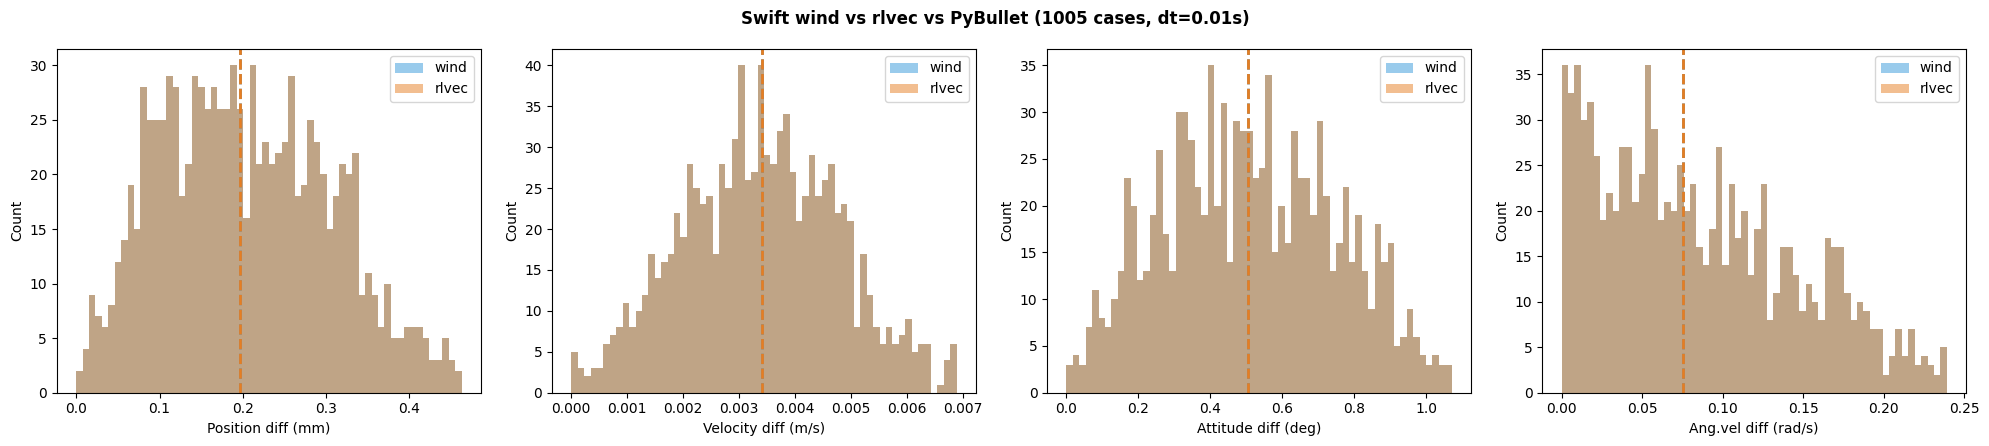

In [13]:
# Cell 9: Plots
colors = {'wind':'#3498db','rlvec':'#e67e22'}
fig, axes = plt.subplots(1, 4, figsize=(20,4.5))
fig.suptitle(f'Swift wind vs rlvec vs PyBullet ({len(test_cases)} cases, dt={dt}s)', fontweight='bold')
for ax, key, xl in zip(axes, ['pos_err','vel_err','att_err','om_err'],
        ['Position diff (mm)','Velocity diff (m/s)','Attitude diff (deg)','Ang.vel diff (rad/s)']):
    for n in names:
        d = np.array([r[key] for r in res[n]]); clip = np.percentile(d, 99)
        ax.hist(d[d<=clip], bins=60, alpha=0.5, color=colors[n], label=n, edgecolor='none')
        ax.axvline(np.median(d), color=colors[n], ls='--', lw=2)
    ax.set_xlabel(xl); ax.set_ylabel('Count'); ax.legend()
fig.tight_layout()
fig.savefig('comparison_wind_rlvec.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Cell 10: Download
from google.colab import files
for f in ['comparison_wind_rlvec.png','results_wind_rlvec.txt']:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>